# Ensamble XGBoost + CatBoost para pronóstico mensual de O3

Objetivo:
predecir el número mensual de días con máximo diario de O3 >= 155 ppb
durante la temporada 15 de febrero - 15 de junio.

Flujo:

1. Preparar O3, temperatura, viento, RH, UV y NO2.
2. Construir base mensual.
3. Comparar pequeños conjuntos de variables con validación temporal.
4. Entrenar XGBoost y CatBoost.
5. Buscar el peso óptimo del ensamble SOLO con validación pre-2019.
6. Evaluar una sola vez en TEST 2019-2025.
7. Reentrenar modelos de producción con 2010-2025.
8. Pronosticar 2026 usando climatología construida SOLO hasta 2025.
9. Guardar modelos, configuración y resultados.

Nota:
el intervalo Minimo/Maximo construido con MAE/RMSE es descriptivo,
no un intervalo probabilístico formal.


In [1]:
# ============================================================
# 0. INSTALACIÓN (solo si hace falta)
# ============================================================

#%pip install xgboost catboost shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
import xgboost as xgb

from catboost import CatBoostRegressor

try:
    import shap
except ImportError:
    shap = None
    print("SHAP no instalado. Ejecuta: %pip install shap")

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.width",
    180
)

SEED = 42

np.random.seed(
    SEED
)

print(
    "Python:",
    sys.executable
)

print(
    "XGBoost:",
    xgb.__version__
)


Python: /home/eradvgx/miniconda3/envs/ds/bin/python
XGBoost: 3.4.1


In [3]:
# ============================================================
# 2. PARÁMETROS
# ============================================================

YEAR1 = 2010

UMBRAL_O3 = 155

ANIO_TRAIN_FIN = 2018

ANIO_TEST_INI = 2019

ANIO_TEST_FIN = 2025

ANIO_PRONOSTICO = 2026

# Años usados para validación temporal.
# Cada año se predice entrenando únicamente con años anteriores.
ANIOS_CV = list(
    range(
        2014,
        2019
    )
)

# Pesos candidatos del ensamble.
PESOS_XGB = np.round(
    np.arange(
        0.0,
        1.01,
        0.05
    ),
    2
)

# Directorio donde se guardarán los resultados.
CARPETA_SALIDA = (
    r"/data/SEDEMA/Pronostico_o3/resultados_ensemble"
)

# En Windows puedes reemplazarlo por algo como:
#
# CARPETA_SALIDA = (
#     r"C:\Users\erdav\OneDrive\Documentos"
#     r"\Pronostico_o3\scripts\ensemble"
# )

os.makedirs(
    CARPETA_SALIDA,
    exist_ok=True
)


In [4]:
# ============================================================
# 3. CARGA DE DATOS
# ============================================================
#
# Estas rutas vienen de tu notebook actual.
# Modifícalas si cambia la ubicación.
# ============================================================

# O3 histórico + 2026
o3_h = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/rama/o3.csv",
    low_memory=False
)

o3_h26 = pd.read_csv(
    r"/data/SEDEMA/Bases/2026/rama/o32026_ago.csv",
    low_memory=False
)

o3_h = (
    pd.concat(
        [
            o3_h,
            o3_h26
        ],
        ignore_index=True
    )
    .drop_duplicates()
)


# Temperatura
temperatura = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/redmet/tmp.csv",
    low_memory=False
)

temperatura26 = pd.read_csv(
    r"/data/SEDEMA/Bases/2026/redmet/tmp2026_ago.csv",
    low_memory=False
)

temperatura = (
    pd.concat(
        [
            temperatura,
            temperatura26
        ],
        ignore_index=True
    )
    .drop_duplicates()
)


# Viento
v_viento = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/redmet/wsp.csv",
    low_memory=False
)

v_viento26 = pd.read_csv(
    r"/data/SEDEMA/Bases/2026/redmet/wsp2026_ago.csv",
    low_memory=False
)

v_viento = (
    pd.concat(
        [
            v_viento,
            v_viento26
        ],
        ignore_index=True
    )
    .drop_duplicates()
)


# NO2
no2 = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/rama/no2_completo.csv",
    low_memory=False
)


# Humedad relativa NASA
rh = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/nasa/rh_completo.csv",
    low_memory=False
)


# UV NASA
uv = pd.read_csv(
    r"/data/SEDEMA/Bases/historicos/nasa/uv_completo.csv",
    low_memory=False
)

print(
    "O3:",
    o3_h.shape
)

print(
    "TMP:",
    temperatura.shape
)

print(
    "WSP:",
    v_viento.shape
)

print(
    "NO2:",
    no2.shape
)

print(
    "RH:",
    rh.shape
)

print(
    "UV:",
    uv.shape
)


O3: (7975680, 5)
TMP: (5602464, 5)
WSP: (5693496, 5)
NO2: (7158000, 5)
RH: (146088, 5)
UV: (146088, 7)


Si ya cargaste las bases en otras celdas, puedes omitir la celda anterior
y continuar desde las funciones auxiliares.


In [5]:
# ============================================================
# 4. FUNCIONES AUXILIARES
# ============================================================

def convertir_fecha(
    serie
):
    try:
        return pd.to_datetime(
            serie,
            format="mixed",
            errors="coerce"
        )

    except (
        TypeError,
        ValueError
    ):
        return pd.to_datetime(
            serie,
            errors="coerce"
        )


def revisar_columnas(
    df,
    necesarias,
    nombre="DataFrame"
):
    faltantes = [
        c
        for c in necesarias
        if c not in df.columns
    ]

    if faltantes:
        raise ValueError(
            f"{nombre} no contiene: {faltantes}\n"
            f"Disponibles: {df.columns.tolist()}"
        )


def media_segura(
    x
):
    x = pd.to_numeric(
        x,
        errors="coerce"
    )

    if x.notna().sum() == 0:
        return np.nan

    return x.mean()


def maximo_seguro(
    x
):
    x = pd.to_numeric(
        x,
        errors="coerce"
    )

    if x.notna().sum() == 0:
        return np.nan

    return x.max()


def contar_dias_evento(
    x,
    umbral=UMBRAL_O3
):
    x = pd.to_numeric(
        x,
        errors="coerce"
    )

    if x.notna().sum() == 0:
        return np.nan

    return int(
        (
            x
            >=
            umbral
        ).sum()
    )


def mascara_temporada_o3(
    fecha
):
    mes = fecha.dt.month

    dia = fecha.dt.day

    return (
        (
            (mes == 2)
            &
            (dia >= 15)
        )
        |
        mes.isin(
            [
                3,
                4,
                5
            ]
        )
        |
        (
            (mes == 6)
            &
            (dia <= 15)
        )
    )


def limpiar_nasa(
    df,
    columnas
):
    df = df.copy()

    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

            # NASA POWER usa frecuentemente -999
            # como indicador de dato faltante.
            df.loc[
                df[col]
                <=
                -900,
                col
            ] = np.nan

    return df


def metricas_regresion(
    y_real,
    y_pred
):
    y_real = np.asarray(
        y_real,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    error = (
        y_real
        -
        y_pred
    )

    return {
        "ME":
            float(
                np.mean(
                    error
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_real,
                        y_pred
                    )
                )
            ),

        "MAE":
            float(
                mean_absolute_error(
                    y_real,
                    y_pred
                )
            ),

        "R2":
            float(
                r2_score(
                    y_real,
                    y_pred
                )
            )
    }


def crear_modelo_xgb():
    # Se conservan los hiperparámetros de tu modelo actual
    # para que la comparación sea justa.
    return XGBRegressor(
        objective=
            "reg:squarederror",

        n_estimators=
            300,

        learning_rate=
            0.03,

        max_depth=
            1,

        subsample=
            0.8,

        colsample_bytree=
            0.8,

        min_child_weight=
            1,

        reg_alpha=
            0.0,

        reg_lambda=
            1.0,

        random_state=
            SEED,

        n_jobs=
            -1,

        tree_method=
            "hist"
    )


def crear_modelo_cat():
    # Dataset mensual pequeño:
    # se usa un CatBoost poco profundo y regularizado.
    return CatBoostRegressor(
        iterations=
            400,

        depth=
            3,

        learning_rate=
            0.03,

        loss_function=
            "RMSE",

        eval_metric=
            "RMSE",

        l2_leaf_reg=
            8.0,

        random_strength=
            0.5,

        random_seed=
            SEED,

        verbose=
            False,

        allow_writing_files=
            False
    )


def grafica_real_predicho(
    df,
    titulo
):
    plt.figure(
        figsize=(
            12,
            5
        )
    )

    plt.plot(
        np.arange(
            len(df)
        ),
        df["real"],
        marker="o",
        label="Real"
    )

    plt.plot(
        np.arange(
            len(df)
        ),
        df["pred_xgb"],
        marker="o",
        label="XGBoost"
    )

    plt.plot(
        np.arange(
            len(df)
        ),
        df["pred_cat"],
        marker="o",
        label="CatBoost"
    )

    plt.plot(
        np.arange(
            len(df)
        ),
        df["pred_ensemble"],
        marker="o",
        linewidth=2,
        label="Ensamble"
    )

    plt.xlabel(
        "Observación mensual"
    )

    plt.ylabel(
        "Número de días >=155 ppb"
    )

    plt.title(
        titulo
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


In [6]:
# ============================================================
# 5. PREPARAR O3 / TMP / WSP
# ============================================================

revisar_columnas(
    temperatura,
    [
        "date",
        "valor"
    ],
    "temperatura"
)

revisar_columnas(
    v_viento,
    [
        "date",
        "valor"
    ],
    "v_viento"
)

revisar_columnas(
    o3_h,
    [
        "date",
        "id_station",
        "valor"
    ],
    "o3_h"
)

temperatura_mod = temperatura.copy()

viento_mod = v_viento.copy()

o3_mod = o3_h.copy()


for df in [
    temperatura_mod,
    viento_mod,
    o3_mod
]:
    df["date"] = convertir_fecha(
        df["date"]
    )

    df["valor"] = pd.to_numeric(
        df["valor"],
        errors="coerce"
    )


# Mismo filtro de estaciones usado en tu notebook.
estaciones_excluir = [
    "ACO",
    "AJU",
    "INN",
    "MON",
    "MPA"
]

mask_excluir = (
    (
        o3_mod[
            "date"
        ].dt.year
        >=
        2017
    )
    &
    o3_mod[
        "id_station"
    ].isin(
        estaciones_excluir
    )
)

o3_mod = (
    o3_mod
    .loc[
        ~mask_excluir
    ]
    .copy()
)


temperatura_mod = temperatura_mod[
    temperatura_mod[
        "date"
    ].dt.year
    >=
    YEAR1
].copy()


viento_mod = viento_mod[
    viento_mod[
        "date"
    ].dt.year
    >=
    YEAR1
].copy()


o3_mod = o3_mod[
    o3_mod[
        "date"
    ].dt.year
    >=
    YEAR1
].copy()


In [9]:
# ============================================================
# 6. AGREGACIÓN DIARIA
# ============================================================

# Temperatura promedio diario
tmp_d = temperatura_mod.copy()

tmp_d["date"] = (
    tmp_d[
        "date"
    ]
    .dt
    .normalize()
)

tmp_d = (
    tmp_d
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        tmp_prom=(
            "valor",
            "mean"
        )
    )
)


# Viento promedio diario
wsp_d = viento_mod.copy()

wsp_d["date"] = (
    wsp_d[
        "date"
    ]
    .dt
    .normalize()
)

wsp_d = (
    wsp_d
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        wsp_prom=(
            "valor",
            "mean"
        )
    )
)


# Máximo diario de O3 de la red
o3_d = o3_mod.copy()

o3_d["date"] = (
    o3_d[
        "date"
    ]
    .dt
    .normalize()
)

o3_d = (
    o3_d
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        valor=(
            "valor",
            "max"
        )
    )
)

display(
    o3_d.head()
)


,date,valor
0,2010-01-01,82.0
1,2010-01-02,67.0
2,2010-01-03,45.0
3,2010-01-04,58.0
4,2010-01-05,77.0


In [10]:
# ============================================================
# 7. NO2
# ============================================================

revisar_columnas(
    no2,
    [
        "date",
        "valor"
    ],
    "no2"
)

no2_mod = no2.copy()

no2_mod["date"] = convertir_fecha(
    no2_mod[
        "date"
    ]
)

no2_mod["valor"] = pd.to_numeric(
    no2_mod[
        "valor"
    ],
    errors="coerce"
)

no2_mod = no2_mod[
    no2_mod[
        "date"
    ].dt.year
    >=
    YEAR1
].copy()

no2_mod["date"] = (
    no2_mod[
        "date"
    ]
    .dt
    .normalize()
)

no2_d = (
    no2_mod
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        no2_max=(
            "valor",
            "max"
        )
    )
)


In [11]:
# ============================================================
# 8. UV
# ============================================================

uv_mod = uv.copy()

if "uva" not in uv_mod.columns:
    revisar_columnas(
        uv_mod,
        [
            "ALLSKY_SFC_UVA",
            "ALLSKY_SFC_UVB",
            "DY",
            "MO",
            "YEAR"
        ],
        "uv"
    )

    uv_mod = uv_mod.rename(
        columns={
            "ALLSKY_SFC_UVA":
                "uva",

            "ALLSKY_SFC_UVB":
                "uvb"
        }
    )

uv_mod = limpiar_nasa(
    uv_mod,
    [
        "uva",
        "uvb",
        "DY",
        "MO",
        "YEAR"
    ]
)

revisar_columnas(
    uv_mod,
    [
        "uva",
        "uvb",
        "DY",
        "MO",
        "YEAR"
    ],
    "uv"
)

uv_d = (
    uv_mod
    .groupby(
        [
            "DY",
            "MO",
            "YEAR"
        ],
        as_index=False
    )
    .agg(
        uva_max=(
            "uva",
            maximo_seguro
        ),

        uvb_max=(
            "uvb",
            maximo_seguro
        )
    )
)

uv_d["date"] = pd.to_datetime(
    dict(
        year=
            uv_d[
                "YEAR"
            ],

        month=
            uv_d[
                "MO"
            ],

        day=
            uv_d[
                "DY"
            ]
    ),
    errors="coerce"
)

uv_d = uv_d.drop(
    columns=[
        "DY",
        "MO",
        "YEAR"
    ]
)


In [12]:
# ============================================================
# 9. HUMEDAD RELATIVA
# ============================================================

rh_mod = rh.copy()

if "rh" not in rh_mod.columns:
    revisar_columnas(
        rh_mod,
        [
            "RH2M",
            "DY",
            "MO",
            "YEAR"
        ],
        "rh"
    )

    rh_mod = rh_mod.rename(
        columns={
            "RH2M":
                "rh"
        }
    )

rh_mod = limpiar_nasa(
    rh_mod,
    [
        "rh",
        "DY",
        "MO",
        "YEAR"
    ]
)

revisar_columnas(
    rh_mod,
    [
        "rh",
        "DY",
        "MO",
        "YEAR"
    ],
    "rh"
)

rh_d = (
    rh_mod
    .groupby(
        [
            "DY",
            "MO",
            "YEAR"
        ],
        as_index=False
    )
    .agg(
        rh_prom=(
            "rh",
            media_segura
        )
    )
)

rh_d["date"] = pd.to_datetime(
    dict(
        year=
            rh_d[
                "YEAR"
            ],

        month=
            rh_d[
                "MO"
            ],

        day=
            rh_d[
                "DY"
            ]
    ),
    errors="coerce"
)

rh_d = rh_d.drop(
    columns=[
        "DY",
        "MO",
        "YEAR"
    ]
)


In [13]:
# ============================================================
# 10. UNIR BASE DIARIA
# ============================================================

base_full = (
    o3_d
    .merge(
        no2_d,
        on="date",
        how="left"
    )
    .merge(
        tmp_d,
        on="date",
        how="left"
    )
    .merge(
        wsp_d,
        on="date",
        how="left"
    )
    .merge(
        uv_d,
        on="date",
        how="left"
    )
    .merge(
        rh_d,
        on="date",
        how="left"
    )
)

print(
    base_full.shape
)

display(
    base_full.head()
)


(6087, 8)


,date,valor,no2_max,tmp_prom,wsp_prom,uva_max,uvb_max,rh_prom
0,2010-01-01,82.0,57.0,14.300595,1.760938,44.55,1.41,73.877917
1,2010-01-02,67.0,84.0,12.308333,1.290104,34.55,1.15,80.350417
2,2010-01-03,45.0,51.0,11.819048,1.641053,19.74,0.68,82.908750
3,2010-01-04,58.0,61.0,10.813691,1.966492,35.97,1.16,77.625833
4,2010-01-05,77.0,106.0,10.779167,1.349215,40.11,1.33,71.060833


In [14]:
# ============================================================
# 11. BASE MENSUAL
# ============================================================

temporada_full = base_full[
    mascara_temporada_o3(
        base_full[
            "date"
        ]
    )
].copy()

temporada_full[
    "year"
] = temporada_full[
    "date"
].dt.year

temporada_full[
    "month"
] = temporada_full[
    "date"
].dt.month


o3_temp_full = (
    temporada_full
    .groupby(
        [
            "year",
            "month"
        ],
        as_index=False
    )
    .agg(
        ndias=(
            "valor",
            contar_dias_evento
        ),

        tmp_prom=(
            "tmp_prom",
            media_segura
        ),

        wsp_prom=(
            "wsp_prom",
            media_segura
        ),

        rh_prom=(
            "rh_prom",
            media_segura
        ),

        uva_max=(
            "uva_max",
            maximo_seguro
        ),

        uvb_max=(
            "uvb_max",
            maximo_seguro
        ),

        no2_max=(
            "no2_max",
            maximo_seguro
        )
    )
    .sort_values(
        [
            "year",
            "month"
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Base mensual:",
    o3_temp_full.shape
)

display(
    o3_temp_full
)


Base mensual: (85, 9)


,year,month,ndias,tmp_prom,wsp_prom,rh_prom,uva_max,uvb_max,no2_max
0,2010,2,0,14.356216,1.646025,64.707351,61.43,2.36,139.0
1,2010,3,3,18.076417,1.750078,52.109556,66.58,2.52,134.0
2,2010,4,4,18.277643,1.686909,49.885597,69.93,2.71,124.0
3,2010,5,5,20.158042,1.724572,50.094261,68.60,2.71,143.0
4,2010,6,5,19.921353,1.635680,57.172000,62.50,2.38,116.0
...,...,...,...,...,...,...,...,...,...
80,2026,2,2,17.585410,1.978744,47.856518,60.23,2.11,121.0
81,2026,3,2,16.804109,2.091705,57.208347,66.98,2.37,84.0
82,2026,4,1,19.573127,2.024902,58.076458,66.90,2.60,95.0
83,2026,5,0,19.723149,1.978427,60.997419,67.40,2.50,92.0


In [15]:
# ============================================================
# 12. CORRELACIÓN
# ============================================================

VARIABLES_COR = [
    "ndias",
    "tmp_prom",
    "wsp_prom",
    "rh_prom",
    "uva_max",
    "uvb_max",
    "no2_max"
]

display(
    o3_temp_full[
        VARIABLES_COR
    ]
    .corr(
        method="pearson"
    )
)


,ndias,tmp_prom,wsp_prom,rh_prom,uva_max,uvb_max,no2_max
ndias,1.000000,0.331134,-0.120867,-0.232482,0.114584,0.207079,0.303168
tmp_prom,0.331134,1.000000,0.158005,-0.166086,0.417680,0.425955,-0.330742
wsp_prom,-0.120867,0.158005,1.000000,-0.275117,0.354624,0.331839,-0.267310
rh_prom,-0.232482,-0.166086,-0.275117,1.000000,-0.126280,-0.067857,-0.375779
uva_max,0.114584,0.417680,0.354624,-0.126280,1.000000,0.865005,-0.018126
uvb_max,0.207079,0.425955,0.331839,-0.067857,0.865005,1.000000,0.067558
no2_max,0.303168,-0.330742,-0.267310,-0.375779,-0.018126,0.067558,1.000000


## Conjuntos de variables candidatos

No vamos a decidir mirando el test.

Se comparan tres alternativas usando únicamente validación temporal
pre-2019:

- ambas UV
- solo UVA
- solo UVB

Esto permite comprobar si eliminar una de las dos variables UV
redundantes ayuda.


In [17]:
# ============================================================
# 13. CONJUNTOS DE VARIABLES
# ============================================================

FEATURE_SETS = {
    "ambas_uv": [
        "year",
        "month",
        "tmp_prom",
        "wsp_prom",
        "rh_prom",
        "uva_max",
        "uvb_max",
        "no2_max"
    ],

    "solo_uva": [
        "year",
        "month",
        "tmp_prom",
        "wsp_prom",
        "rh_prom",
        "uva_max",
        "no2_max"
    ],

    "solo_uvb": [
        "year",
        "month",
        "tmp_prom",
        "wsp_prom",
        "rh_prom",
        "uvb_max",
        "no2_max"
    ]
}

for nombre, features in FEATURE_SETS.items():
    print(
        nombre,
        "->",
        features
    )


ambas_uv -> ['year', 'month', 'tmp_prom', 'wsp_prom', 'rh_prom', 'uva_max', 'uvb_max', 'no2_max']
solo_uva -> ['year', 'month', 'tmp_prom', 'wsp_prom', 'rh_prom', 'uva_max', 'no2_max']
solo_uvb -> ['year', 'month', 'tmp_prom', 'wsp_prom', 'rh_prom', 'uvb_max', 'no2_max']


In [18]:
# ============================================================
# 14. VALIDACIÓN TEMPORAL
# ============================================================

def predicciones_cv_temporal(
    datos,
    features,
    anios_cv=ANIOS_CV
):
    predicciones = []

    for anio_val in anios_cv:

        train_cv = datos[
            datos[
                "year"
            ]
            <
            anio_val
        ].copy()

        val_cv = datos[
            datos[
                "year"
            ]
            ==
            anio_val
        ].copy()

        if (
            train_cv.empty
            or
            val_cv.empty
        ):
            continue

        X_train = train_cv[
            features
        ].astype(float)

        y_train = train_cv[
            "ndias"
        ].astype(float)

        X_val = val_cv[
            features
        ].astype(float)

        y_val = val_cv[
            "ndias"
        ].astype(float)


        modelo_xgb = crear_modelo_xgb()

        modelo_xgb.fit(
            X_train,
            y_train
        )

        pred_xgb = modelo_xgb.predict(
            X_val
        )


        modelo_cat = crear_modelo_cat()

        modelo_cat.fit(
            X_train,
            y_train
        )

        pred_cat = modelo_cat.predict(
            X_val
        )


        tmp = val_cv[
            [
                "year",
                "month",
                "ndias"
            ]
        ].copy()

        tmp = tmp.rename(
            columns={
                "ndias":
                    "real"
            }
        )

        tmp[
            "pred_xgb"
        ] = pred_xgb

        tmp[
            "pred_cat"
        ] = pred_cat

        predicciones.append(
            tmp
        )


    if not predicciones:
        raise ValueError(
            "No fue posible generar "
            "predicciones de CV."
        )

    return pd.concat(
        predicciones,
        ignore_index=True
    )


def optimizar_peso_ensemble(
    cv
):
    filas = []

    for peso_xgb in PESOS_XGB:

        peso_cat = (
            1.0
            -
            peso_xgb
        )

        pred = (
            peso_xgb
            *
            cv[
                "pred_xgb"
            ]
            +
            peso_cat
            *
            cv[
                "pred_cat"
            ]
        )

        m = metricas_regresion(
            cv[
                "real"
            ],
            pred
        )

        filas.append({
            "peso_xgb":
                float(
                    peso_xgb
                ),

            "peso_cat":
                float(
                    peso_cat
                ),

            "RMSE":
                m[
                    "RMSE"
                ],

            "MAE":
                m[
                    "MAE"
                ],

            "ME":
                m[
                    "ME"
                ]
        })


    tabla = (
        pd.DataFrame(
            filas
        )
        .sort_values(
            [
                "RMSE",
                "MAE"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    return tabla


In [19]:
# ============================================================
# 15. COMPARAR FEATURE SETS + ENSAMBLE EN CV
# ============================================================

resumen_cv = []

objetos_cv = {}

for nombre_set, features in FEATURE_SETS.items():

    print(
        "\nEvaluando:",
        nombre_set
    )

    cv = predicciones_cv_temporal(
        datos=o3_temp_full[
            o3_temp_full[
                "year"
            ]
            <=
            ANIO_TRAIN_FIN
        ].copy(),

        features=features
    )


    tabla_pesos = (
        optimizar_peso_ensemble(
            cv
        )
    )


    mejor_peso = (
        tabla_pesos
        .iloc[
            0
        ]
    )


    peso_xgb = float(
        mejor_peso[
            "peso_xgb"
        ]
    )

    peso_cat = float(
        mejor_peso[
            "peso_cat"
        ]
    )


    cv[
        "pred_ensemble"
    ] = (
        peso_xgb
        *
        cv[
            "pred_xgb"
        ]
        +
        peso_cat
        *
        cv[
            "pred_cat"
        ]
    )


    m_xgb = metricas_regresion(
        cv[
            "real"
        ],
        cv[
            "pred_xgb"
        ]
    )

    m_cat = metricas_regresion(
        cv[
            "real"
        ],
        cv[
            "pred_cat"
        ]
    )

    m_ens = metricas_regresion(
        cv[
            "real"
        ],
        cv[
            "pred_ensemble"
        ]
    )


    resumen_cv.append({
        "feature_set":
            nombre_set,

        "n_features":
            len(
                features
            ),

        "peso_xgb":
            peso_xgb,

        "peso_cat":
            peso_cat,

        "RMSE_xgb":
            m_xgb[
                "RMSE"
            ],

        "RMSE_cat":
            m_cat[
                "RMSE"
            ],

        "RMSE_ensemble":
            m_ens[
                "RMSE"
            ],

        "MAE_ensemble":
            m_ens[
                "MAE"
            ],

        "ME_ensemble":
            m_ens[
                "ME"
            ]
    })


    objetos_cv[
        nombre_set
    ] = {
        "cv":
            cv,

        "tabla_pesos":
            tabla_pesos,

        "features":
            features
    }


resumen_cv = (
    pd.DataFrame(
        resumen_cv
    )
    .sort_values(
        [
            "RMSE_ensemble",
            "MAE_ensemble"
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    resumen_cv
)



Evaluando: ambas_uv

Evaluando: solo_uva

Evaluando: solo_uvb


,feature_set,n_features,peso_xgb,peso_cat,RMSE_xgb,RMSE_cat,RMSE_ensemble,MAE_ensemble,ME_ensemble
0,solo_uva,7,0.0,1.0,1.845570,1.648671,1.648671,1.322671,-0.282644
1,ambas_uv,8,0.5,0.5,1.809853,1.801170,1.753120,1.373629,-0.241222
2,solo_uvb,7,0.3,0.7,1.910370,1.815201,1.794050,1.454718,-0.296718


Feature set elegido: solo_uva
Variables: ['year', 'month', 'tmp_prom', 'wsp_prom', 'rh_prom', 'uva_max', 'no2_max']
Peso XGBoost: 0.0
Peso CatBoost: 1.0


,peso_xgb,peso_cat,RMSE,MAE,ME
0,0.00,1.00,1.648671,1.322671,-0.282644
1,0.05,0.95,1.648799,1.323634,-0.277172
2,0.10,0.90,1.650011,1.324597,-0.271699
3,0.15,0.85,1.652304,1.325560,-0.266226
4,0.20,0.80,1.655676,1.326523,-0.260754
5,0.25,0.75,1.660117,1.327486,-0.255281
6,0.30,0.70,1.665621,1.328449,-0.249808
7,0.35,0.65,1.672177,1.329412,-0.244335
8,0.40,0.60,1.679772,1.330376,-0.238863
9,0.45,0.55,1.688393,1.331339,-0.233390


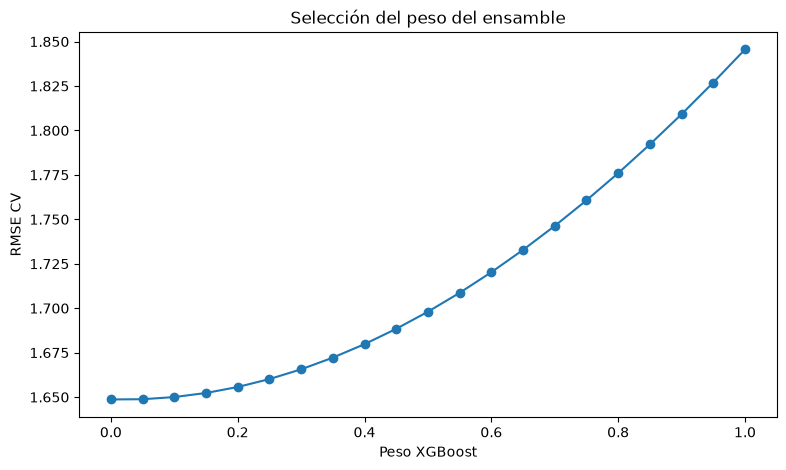

In [20]:
# ============================================================
# 16. SELECCIONAR CONFIGURACIÓN FINAL SIN VER EL TEST
# ============================================================

MEJOR_FEATURE_SET = (
    resumen_cv
    .iloc[
        0
    ][
        "feature_set"
    ]
)

FEATURES_FINAL = (
    FEATURE_SETS[
        MEJOR_FEATURE_SET
    ]
)

PESO_XGB = float(
    resumen_cv
    .iloc[
        0
    ][
        "peso_xgb"
    ]
)

PESO_CAT = float(
    resumen_cv
    .iloc[
        0
    ][
        "peso_cat"
    ]
)

print(
    "Feature set elegido:",
    MEJOR_FEATURE_SET
)

print(
    "Variables:",
    FEATURES_FINAL
)

print(
    "Peso XGBoost:",
    PESO_XGB
)

print(
    "Peso CatBoost:",
    PESO_CAT
)

# Curva de pesos del feature set elegido.
tabla_pesos_final = (
    objetos_cv[
        MEJOR_FEATURE_SET
    ][
        "tabla_pesos"
    ]
)

display(
    tabla_pesos_final.head(
        10
    )
)

plt.figure(
    figsize=(
        9,
        5
    )
)

plt.plot(
    tabla_pesos_final[
        "peso_xgb"
    ],
    tabla_pesos_final[
        "RMSE"
    ],
    marker="o"
)

plt.xlabel(
    "Peso XGBoost"
)

plt.ylabel(
    "RMSE CV"
)

plt.title(
    "Selección del peso del ensamble"
)

plt.show()


# TEST FINAL 2019–2025

A partir de aquí ya NO se cambia:

- conjunto de variables
- peso del ensamble
- hiperparámetros

El test se usa únicamente para estimar desempeño fuera de muestra.


In [21]:
# ============================================================
# 17. TRAIN FINAL Y TEST
# ============================================================

train_final = o3_temp_full[
    o3_temp_full[
        "year"
    ]
    <=
    ANIO_TRAIN_FIN
].copy()


test_final = o3_temp_full[
    o3_temp_full[
        "year"
    ]
    .between(
        ANIO_TEST_INI,
        ANIO_TEST_FIN
    )
].copy()


X_train_final = train_final[
    FEATURES_FINAL
].astype(float)

y_train_final = train_final[
    "ndias"
].astype(float)


X_test_final = test_final[
    FEATURES_FINAL
].astype(float)

y_test_final = test_final[
    "ndias"
].astype(float)


print(
    "Train:",
    X_train_final.shape
)

print(
    "Test:",
    X_test_final.shape
)


Train: (45, 7)
Test: (35, 7)


In [22]:
# ============================================================
# 18. ENTRENAR LOS DOS MODELOS
# ============================================================

modelo_xgb_final = crear_modelo_xgb()

modelo_xgb_final.fit(
    X_train_final,
    y_train_final
)


modelo_cat_final = crear_modelo_cat()

modelo_cat_final.fit(
    X_train_final,
    y_train_final
)


pred_xgb_test = (
    modelo_xgb_final
    .predict(
        X_test_final
    )
)


pred_cat_test = (
    modelo_cat_final
    .predict(
        X_test_final
    )
)


pred_ensemble_test = (
    PESO_XGB
    *
    pred_xgb_test
    +
    PESO_CAT
    *
    pred_cat_test
)

# Número de días no puede ser negativo.
pred_ensemble_test = np.maximum(
    pred_ensemble_test,
    0
)


In [23]:
# ============================================================
# 19. MÉTRICAS TEST
# ============================================================

metricas_test = pd.DataFrame([
    {
        "modelo":
            "XGBoost",
        **
        metricas_regresion(
            y_test_final,
            pred_xgb_test
        )
    },

    {
        "modelo":
            "CatBoost",
        **
        metricas_regresion(
            y_test_final,
            pred_cat_test
        )
    },

    {
        "modelo":
            "XGBoost + CatBoost",
        **
        metricas_regresion(
            y_test_final,
            pred_ensemble_test
        )
    }
])

display(
    metricas_test
)


,modelo,ME,RMSE,MAE,R2
0,XGBoost,-0.895980,2.249860,1.693207,-0.276933
1,CatBoost,-0.914887,2.249227,1.695917,-0.276215
2,XGBoost + CatBoost,-0.914887,2.249227,1.695917,-0.276215


,year,month,real,pred_xgb,pred_cat,pred_ensemble,error_ensemble
45,2019,2,0,-0.149007,0.057429,0.057429,-0.057429
46,2019,3,1,0.010727,0.102059,0.102059,0.897941
47,2019,4,3,1.176043,1.390056,1.390056,1.609944
48,2019,5,0,4.265278,3.964810,3.964810,-3.964810
49,2019,6,0,0.784957,0.484447,0.484447,-0.484447
50,2020,2,0,0.195661,0.361870,0.361870,-0.361870
51,2020,3,0,1.197431,1.287792,1.287792,-1.287792
52,2020,4,0,2.732447,2.489321,2.489321,-2.489321
53,2020,5,0,1.785970,2.733559,2.733559,-2.733559
54,2020,6,0,1.331677,1.275514,1.275514,-1.275514


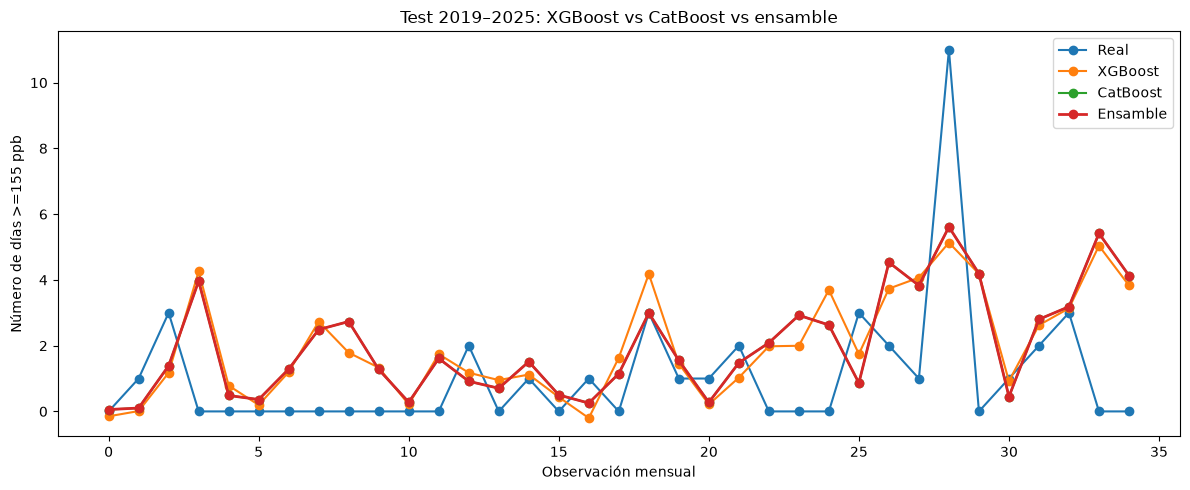

In [24]:
# ============================================================
# 20. PREDICCIONES TEST
# ============================================================

resultados_test = test_final[
    [
        "year",
        "month",
        "ndias"
    ]
].copy()

resultados_test = resultados_test.rename(
    columns={
        "ndias":
            "real"
    }
)

resultados_test[
    "pred_xgb"
] = pred_xgb_test

resultados_test[
    "pred_cat"
] = pred_cat_test

resultados_test[
    "pred_ensemble"
] = pred_ensemble_test

resultados_test[
    "error_ensemble"
] = (
    resultados_test[
        "real"
    ]
    -
    resultados_test[
        "pred_ensemble"
    ]
)

display(
    resultados_test
)

grafica_real_predicho(
    resultados_test,
    titulo=(
        "Test 2019–2025: "
        "XGBoost vs CatBoost vs ensamble"
    )
)


In [25]:
# ============================================================
# 21. ¿LOS MODELOS SE EQUIVOCAN DISTINTO?
# ============================================================

error_xgb = (
    y_test_final
    .to_numpy()
    -
    pred_xgb_test
)

error_cat = (
    y_test_final
    .to_numpy()
    -
    pred_cat_test
)

correlacion_errores = float(
    np.corrcoef(
        error_xgb,
        error_cat
    )[
        0,
        1
    ]
)

print(
    "Correlación entre errores XGB y CAT:",
    correlacion_errores
)

# Cuanto menor sea esta correlación,
# mayor puede ser la complementariedad del ensamble.


Correlación entre errores XGB y CAT: 0.9736214661898828


In [26]:
# ============================================================
# 22. IMPORTANCIA DE VARIABLES
# ============================================================

importancia_xgb = (
    pd.DataFrame({
        "variable":
            FEATURES_FINAL,

        "importancia":
            modelo_xgb_final
            .feature_importances_
    })
    .sort_values(
        "importancia",
        ascending=False
    )
)

display(
    importancia_xgb
)


importancia_cat = (
    pd.DataFrame({
        "variable":
            FEATURES_FINAL,

        "importancia":
            modelo_cat_final
            .get_feature_importance()
    })
    .sort_values(
        "importancia",
        ascending=False
    )
)

display(
    importancia_cat
)


,variable,importancia
2,tmp_prom,0.261119
6,no2_max,0.155711
1,month,0.136028
3,wsp_prom,0.133439
4,rh_prom,0.116547
5,uva_max,0.110249
0,year,0.086906


,variable,importancia
2,tmp_prom,35.395624
6,no2_max,16.228875
3,wsp_prom,13.920245
5,uva_max,12.979139
4,rh_prom,8.675868
1,month,7.686596
0,year,5.113652


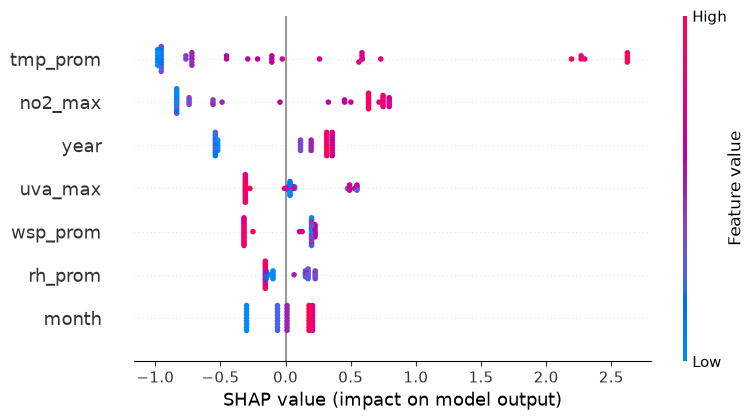

In [27]:
# ============================================================
# 23. SHAP XGBOOST (OPCIONAL)
# ============================================================

if shap is not None:

    explainer = shap.TreeExplainer(
        modelo_xgb_final
    )

    shap_values = (
        explainer
        .shap_values(
            X_train_final
        )
    )

    shap.summary_plot(
        shap_values,
        X_train_final,
        feature_names=
            FEATURES_FINAL,
        show=True
    )

else:

    print(
        "SHAP no disponible."
    )


# MODELOS DE PRODUCCIÓN PARA 2026

La evaluación anterior se hizo con:

- train <= 2018
- test = 2019–2025

Una vez fijada la configuración, para producir el pronóstico 2026
sí conviene volver a entrenar con TODO el histórico disponible
hasta 2025.

Esto NO contamina el test anterior porque la evaluación ya quedó cerrada.


In [28]:
# ============================================================
# 24. REENTRENAR PRODUCCIÓN CON 2010–2025
# ============================================================

produccion = o3_temp_full[
    o3_temp_full[
        "year"
    ]
    <=
    ANIO_TEST_FIN
].copy()


X_prod = produccion[
    FEATURES_FINAL
].astype(float)

y_prod = produccion[
    "ndias"
].astype(float)


modelo_xgb_prod = crear_modelo_xgb()

modelo_xgb_prod.fit(
    X_prod,
    y_prod
)


modelo_cat_prod = crear_modelo_cat()

modelo_cat_prod.fit(
    X_prod,
    y_prod
)

print(
    "Modelos de producción entrenados "
    "con datos hasta 2025."
)


Modelos de producción entrenados con datos hasta 2025.


In [29]:
# ============================================================
# 25. CLIMATOLOGÍA PARA 2026
# ============================================================
#
# IMPORTANTE:
# se construye únicamente con años <= 2025.
# No se usa 2026 para fabricar sus propios predictores.
# ============================================================

FEATURES_CLIMA = [
    c
    for c in FEATURES_FINAL
    if c not in [
        "year",
        "month"
    ]
]


clima_historica = (
    produccion
    .groupby(
        "month",
        as_index=False
    )[
        FEATURES_CLIMA
    ]
    .mean()
)


future_2026 = pd.DataFrame({
    "year":
        ANIO_PRONOSTICO,

    "month":
        np.arange(
            2,
            7
        )
})


future_2026 = (
    future_2026
    .merge(
        clima_historica,
        on="month",
        how="left"
    )
)


X_future_2026 = (
    future_2026[
        FEATURES_FINAL
    ]
    .astype(float)
)


pred_xgb_2026 = (
    modelo_xgb_prod
    .predict(
        X_future_2026
    )
)


pred_cat_2026 = (
    modelo_cat_prod
    .predict(
        X_future_2026
    )
)


pred_ensemble_2026 = (
    PESO_XGB
    *
    pred_xgb_2026
    +
    PESO_CAT
    *
    pred_cat_2026
)

pred_ensemble_2026 = np.maximum(
    pred_ensemble_2026,
    0
)


In [34]:
# ============================================================
# 26. TABLA PRONÓSTICO 2026
# ============================================================

pronostico_2026 = future_2026[
    [
        "year",
        "month"
    ]
].copy()


pronostico_2026[
    "pred_xgb"
] = pred_xgb_2026


pronostico_2026[
    "pred_cat"
] = pred_cat_2026


pronostico_2026[
    "pred_ensemble"
] = pred_ensemble_2026


# Para reporte entero:
pronostico_2026[
    "Promedio"
] = np.round(
    pred_ensemble_2026
).astype(int)

# Promedio entero usando solo XGBoost
pronostico_2026[
    "xgb_prom"
] = np.round(
    pred_xgb_2026
).astype(int)


metricas_ensemble_test = (
    metricas_test[
        metricas_test[
            "modelo"
        ]
        ==
        "XGBoost + CatBoost"
    ]
    .iloc[
        0
    ]
)


MAE_ENSEMBLE = float(
    metricas_ensemble_test[
        "MAE"
    ]
)


RMSE_ENSEMBLE = float(
    metricas_ensemble_test[
        "RMSE"
    ]
)


pronostico_2026[
    "Minimo"
] = np.maximum(
    np.floor(
        pronostico_2026[
            "pred_ensemble"
        ]
        -
        MAE_ENSEMBLE
    ),
    0
).astype(int)


pronostico_2026[
    "Maximo"
] = np.ceil(
    pronostico_2026[
        "pred_ensemble"
    ]
    +
    RMSE_ENSEMBLE
).astype(int)


display(
    pronostico_2026
)

# Total temporada
total_2026 = pd.DataFrame({
    "year":
        [
            ANIO_PRONOSTICO
        ],

    "month":
        [
            "TOTAL"
        ],

    "pred_xgb":
        [
            pronostico_2026[
                "pred_xgb"
            ].sum()
        ],

    "pred_cat":
        [
            pronostico_2026[
                "pred_cat"
            ].sum()
        ],

    "pred_ensemble":
        [
            pronostico_2026[
                "pred_ensemble"
            ].sum()
        ],

    "Promedio":
        [
            pronostico_2026[
                "Promedio"
            ].sum()
        ],
    "xgb_prom":
        [
            pronostico_2026[
                "xgb_prom"
            ].sum()
        ],

    "Minimo":
        [
            pronostico_2026[
                "Minimo"
            ].sum()
        ],

    "Maximo":
        [
            pronostico_2026[
                "Maximo"
            ].sum()
        ]
})


pronostico_2026_total = pd.concat(
    [
        pronostico_2026.assign(
            month=
                pronostico_2026[
                    "month"
                ]
                .astype(str)
        ),

        total_2026
    ],
    ignore_index=True
)


display(
    pronostico_2026_total
)


,year,month,pred_xgb,pred_cat,pred_ensemble,Promedio,xgb_prom,Minimo,Maximo
0,2026,2,1.784571,1.447395,1.447395,1,2,0,4
1,2026,3,2.129481,1.245188,1.245188,1,2,0,4
2,2026,4,1.221834,1.252872,1.252872,1,1,0,4
3,2026,5,3.245398,4.213138,4.213138,4,3,2,7
4,2026,6,0.374456,0.469274,0.469274,0,0,0,3


,year,month,pred_xgb,pred_cat,pred_ensemble,Promedio,xgb_prom,Minimo,Maximo
0,2026,2,1.784571,1.447395,1.447395,1,2,0,4
1,2026,3,2.129481,1.245188,1.245188,1,2,0,4
2,2026,4,1.221834,1.252872,1.252872,1,1,0,4
3,2026,5,3.245398,4.213138,4.213138,4,3,2,7
4,2026,6,0.374456,0.469274,0.469274,0,0,0,3
5,2026,TOTAL,8.755738,8.627866,8.627866,7,8,2,22


## Comparación retrospectiva opcional con 2026 observado

Como actualmente ya tienes datos de 2026,
este bloque permite comparar el pseudo-pronóstico
(hecho sin usar covariables 2026) con lo que realmente ocurrió.

Esto es evaluación retrospectiva, no forma parte del entrenamiento.


In [39]:
# ============================================================
# 27. COMPARACIÓN OPCIONAL CON 2026 REAL
# ============================================================

print(
    "Promedio es predicho con ensamble "
    "y xgb_prom es el predicho promedio de XGBoost puro"
)

real_2026 = (
    o3_temp_full[
        o3_temp_full[
            "year"
        ]
        ==
        ANIO_PRONOSTICO
    ][
        [
            "month",
            "ndias"
        ]
    ]
    .rename(
        columns={
            "ndias":
                "real_2026"
        }
    )
)


comparacion_2026 = (
    pronostico_2026
    .merge(
        real_2026,
        on="month",
        how="left"
    )
)


# Error del ensamble
comparacion_2026[
    "error"
] = (
    comparacion_2026[
        "real_2026"
    ]
    -
    comparacion_2026[
        "pred_ensemble"
    ]
)


# Error de XGBoost redondeado
comparacion_2026[
    "error_xgb"
] = (
    comparacion_2026[
        "real_2026"
    ]
    -
    comparacion_2026[
        "pred_xgb"
    ]
)


display(
    comparacion_2026
)

Promedio es predicho con ensamble y xgb_prom es el predicho promedio de XGBoost puro


,year,month,pred_xgb,pred_cat,pred_ensemble,Promedio,xgb_prom,Minimo,Maximo,real_2026,error,error_xgb
0,2026,2,1.784571,1.447395,1.447395,1,2,0,4,2,0.552605,0.215429
1,2026,3,2.129481,1.245188,1.245188,1,2,0,4,2,0.754812,-0.129481
2,2026,4,1.221834,1.252872,1.252872,1,1,0,4,1,-0.252872,-0.221834
3,2026,5,3.245398,4.213138,4.213138,4,3,2,7,0,-4.213138,-3.245398
4,2026,6,0.374456,0.469274,0.469274,0,0,0,3,0,-0.469274,-0.374456


In [ ]:
# ============================================================
# 28. GUARDAR RESULTADOS
# ============================================================

resumen_cv.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "comparacion_feature_sets_cv.csv"
    ),
    index=False
)


tabla_pesos_final.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "pesos_ensemble_cv.csv"
    ),
    index=False
)


objetos_cv[
    MEJOR_FEATURE_SET
][
    "cv"
].to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "predicciones_cv_mejor_modelo.csv"
    ),
    index=False
)


metricas_test.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "metricas_test_2019_2025.csv"
    ),
    index=False
)


resultados_test.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "predicciones_test_2019_2025.csv"
    ),
    index=False
)


importancia_xgb.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "importancia_xgboost.csv"
    ),
    index=False
)


importancia_cat.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "importancia_catboost.csv"
    ),
    index=False
)


pronostico_2026_total.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "pronostico_2026_ensemble.csv"
    ),
    index=False
)


comparacion_2026.to_csv(
    os.path.join(
        CARPETA_SALIDA,
        "comparacion_pronostico_real_2026.csv"
    ),
    index=False
)


# Modelos de evaluación
modelo_xgb_final.save_model(
    os.path.join(
        CARPETA_SALIDA,
        "xgboost_evaluacion_2010_2018.json"
    )
)


modelo_cat_final.save_model(
    os.path.join(
        CARPETA_SALIDA,
        "catboost_evaluacion_2010_2018.cbm"
    )
)


# Modelos de producción
modelo_xgb_prod.save_model(
    os.path.join(
        CARPETA_SALIDA,
        "xgboost_produccion_hasta_2025.json"
    )
)


modelo_cat_prod.save_model(
    os.path.join(
        CARPETA_SALIDA,
        "catboost_produccion_hasta_2025.cbm"
    )
)


config_ensemble = {
    "feature_set":
        MEJOR_FEATURE_SET,

    "features":
        FEATURES_FINAL,

    "peso_xgb":
        PESO_XGB,

    "peso_cat":
        PESO_CAT,

    "train_evaluacion_fin":
        ANIO_TRAIN_FIN,

    "test_ini":
        ANIO_TEST_INI,

    "test_fin":
        ANIO_TEST_FIN,

    "produccion_hasta":
        ANIO_TEST_FIN,

    "pronostico":
        ANIO_PRONOSTICO,

    "umbral_o3":
        UMBRAL_O3,

    "correlacion_errores_test":
        correlacion_errores,

    "mae_ensemble_test":
        MAE_ENSEMBLE,

    "rmse_ensemble_test":
        RMSE_ENSEMBLE
}


with open(
    os.path.join(
        CARPETA_SALIDA,
        "config_ensemble_xgb_catboost.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config_ensemble,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "Archivos guardados en:"
)

print(
    CARPETA_SALIDA
)


In [ ]:
# ============================================================
# 29. RESUMEN FINAL EN PANTALLA
# ============================================================

print(
    "\nCONFIGURACIÓN ELEGIDA"
)

print(
    "Feature set:",
    MEJOR_FEATURE_SET
)

print(
    "Variables:",
    FEATURES_FINAL
)

print(
    "Peso XGB:",
    PESO_XGB
)

print(
    "Peso CatBoost:",
    PESO_CAT
)


print(
    "\nMÉTRICAS TEST"
)

display(
    metricas_test
)


print(
    "\nCORRELACIÓN DE ERRORES"
)

print(
    correlacion_errores
)


print(
    "\nPRONÓSTICO 2026"
)

display(
    pronostico_2026_total
)
